"Streaming, redes sociales y conciertos: construcción empírica del éxito de un artista musical"
Autora Silvana Contreras
Mayo 

Diccionario categorías: en construcción

In [68]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter


In [1]:
import pandas as pd
import numpy as np

# levanto dataset

In [8]:
df = pd.read_csv("dataset_4913_53.csv") 


In [9]:
df.shape

(4913, 52)

# OFF_cycle

In [32]:
# ============================================================
# Recreación de variable auxiliar off_cycle
# ============================================================

df["off_cycle"] = (
    (df["n_shows_24_25"] == 0) &
    (df["muerto_disuelto"].ne(True).fillna(True))
)

df["off_cycle"] = df["off_cycle"].astype("boolean")

df["off_cycle"].value_counts(dropna=False)

off_cycle
False    4690
True      223
Name: count, dtype: Int64

In [33]:
# ============================================================
# Control de consistencia de off_cycle
# ============================================================

control_off_cycle = (
    df
    .groupby(["off_cycle", "muerto_disuelto"], dropna=False)
    .agg(
        n_artistas=("chartmetric_id", "count"),
        min_shows=("n_shows_24_25", "min"),
        max_shows=("n_shows_24_25", "max"),
        total_shows=("n_shows_24_25", "sum")
    )
    .reset_index()
)

control_off_cycle

,off_cycle,muerto_disuelto,n_artistas,min_shows,max_shows,total_shows
0,False,False,4053,1,179,119381
1,False,True,637,0,0,0
2,True,<NA>,223,0,0,0


In [36]:
df["off_cycle"] = df["off_cycle"].astype(bool)

In [ ]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

In [48]:
df.shape

(4913, 53)

In [49]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'record_label', 'primary_genre', 'sp_followers', 'sp_monthly_listeners',
       'sp_popularity', 'sp_playlist_total_reach', 'ins_followers',
       'twitter_followers', 'tiktok_followers', 'tiktok_likes',
       'ycs_subscribers', 'ycs_views', 'youtube_daily_video_views',
       'youtube_monthly_video_views', 'deezer_fans', 'shazam_count',
       'pandora_lifetime_streams', 'pandora_lifetime_stations_added', 'band',
       'num_sp_editorial_playlists', 'num_sp_playlists',
       'sp_editorial_playlist_total_reach', 'num_am_editorial_playlists',
       'num_am_playlists', 'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
       'num_yt_editorial_playlists', 'num_yt_playlists',
       'yt_playlist_total_reach', 'tiktok_top_video_views',
       'tiktok_top_video_comments', 'tiktok_track_po

# tipos datos

In [ ]:
#recupero de la notebook previa

In [37]:
# 1. Definir el diccionario de tipos basado en tu info
dtypes_dict = {
    'chartmetric_id': 'Int64',
    'artist_name': 'str',
    'country': 'category',
    'pronoun_title': 'category',
    'record_label': 'category',
    'primary_genre': 'category',
    'sp_followers': 'Int64',
    'sp_monthly_listeners': 'Int64',
    'sp_popularity': 'float64',
    'sp_playlist_total_reach': 'float64',
    'ins_followers': 'Int64',
    'twitter_followers': 'Int64',
    'tiktok_followers': 'Int64',
    'tiktok_likes': 'Int64',
    'ycs_subscribers': 'Int64',
    'ycs_views': 'Int64',
    'youtube_daily_video_views': 'Int64',
    'youtube_monthly_video_views': 'Int64',
    'deezer_fans': 'Int64',
    'shazam_count': 'Int64',
    'pandora_lifetime_streams': 'Int64',
    'pandora_lifetime_stations_added': 'Int64',
    'band': 'bool',
    'num_sp_editorial_playlists': 'Int64',
    'num_sp_playlists': 'Int64',
    'sp_editorial_playlist_total_reach': 'float64',
    'num_am_editorial_playlists': 'Int64',
    'num_am_playlists': 'Int64',
    'num_de_editorial_playlists': 'Int64',
    'num_de_playlists': 'Int64',
    'de_playlist_total_reach': 'float64',
    'de_editorial_playlist_total_reach': 'float64',
    'num_az_editorial_playlists': 'Int64',
    'num_az_playlists': 'Int64',
    'num_yt_editorial_playlists': 'Int64',
    'num_yt_playlists': 'Int64',
    'yt_playlist_total_reach': 'float64',
    'tiktok_top_video_views': 'float64',
    'tiktok_top_video_comments': 'float64',
    'tiktok_track_posts': 'float64',
    'n_shows_24_25': 'Int64',
    'n_shows_with_capacity_24_25': 'Int64',
    'capacity_24_25': 'float64',
    'avg_venue_capacity_24_25': 'float64',
    'n_cities_24_25': 'Int64',
    'n_countries_24_25': 'Int64',
    'shows_per_country_24_25': 'float64',
    'major_record_label': 'boolean',
    'pronoun_short': 'category',
    'genre_short': 'category',
    'country_short': 'category',
    'off_cycle': 'bool',
    'muerto_disuelto': 'boolean'
}

# 2. Aplicar la conversión al dataframe df
# Nota: errors='ignore' por si alguna columna no existe en el momento de la carga
df = df.astype(dtypes_dict, errors='ignore')

# 3. Verificación rápida
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     4913 non-null   Int64   
 1   artist_name                        4913 non-null   str     
 2   country                            4909 non-null   category
 3   pronoun_title                      4913 non-null   category
 4   record_label                       4604 non-null   category
 5   primary_genre                      4913 non-null   category
 6   sp_followers                       4907 non-null   Int64   
 7   sp_monthly_listeners               4907 non-null   Int64   
 8   sp_popularity                      4911 non-null   float64 
 9   sp_playlist_total_reach            4913 non-null   float64 
 10  ins_followers                      4580 non-null   Int64   
 11  twitter_followers                  3968 non-null   Int

In [38]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

Filas y columnas: (4913, 53)
Artistas únicos: 4913
Duplicados por chartmetric_id: 0
Nulos en target: 0
Tipo de dato de target: Int64


# conjuntos

In [40]:
# ============================================================
# Paso 2. Agrupación conceptual de variables
# ============================================================

id_cols = [
    "chartmetric_id",
    "artist_name"
]

metadata_cols = [
    "country",
    "country_short",
    "pronoun_title",
    "pronoun_short",
    "record_label",
    "major_record_label",
    "primary_genre",
    "genre_short",
    "band",
    "muerto_disuelto"
]

streaming_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_cols = [
    "sp_playlist_total_reach",
    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "sp_editorial_playlist_total_reach",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "de_playlist_total_reach",
    "de_editorial_playlist_total_reach",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",
    "yt_playlist_total_reach"
]

social_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_top_video_views",
    "tiktok_top_video_comments",
    "tiktok_track_posts"
]

youtube_cols = [
    "ycs_subscribers",
    "ycs_views",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

live_cols = [
    "n_shows_24_25",
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle"
]

# Diccionario de dimensiones
column_groups = {
    "identificacion": id_cols,
    "metadata": metadata_cols,
    "streaming": streaming_cols,
    "playlists": playlist_cols,
    "redes_sociales": social_cols,
    "youtube": youtube_cols,
    "live_events": live_cols
}

# Control de cobertura de columnas
grouped_cols = [col for cols in column_groups.values() for col in cols]

cols_in_groups_not_in_df = sorted(set(grouped_cols) - set(df.columns))
cols_in_df_not_in_groups = sorted(set(df.columns) - set(grouped_cols))

print("Columnas del df:", df.shape[1])
print("Columnas agrupadas:", len(grouped_cols))
print("Columnas agrupadas que no están en df:", cols_in_groups_not_in_df)
print("Columnas del df no agrupadas:", cols_in_df_not_in_groups)

# Resumen por dimensión
for group_name, cols in column_groups.items():
    print(f"{group_name}: {len(cols)} variables")

Columnas del df: 53
Columnas agrupadas: 53
Columnas agrupadas que no están en df: []
Columnas del df no agrupadas: []
identificacion: 2 variables
metadata: 10 variables
streaming: 7 variables
playlists: 15 variables
redes_sociales: 7 variables
youtube: 4 variables
live_events: 8 variables


In [26]:
# ============================================================
# Imputación controlada de ceros estructurales en variables live
# ============================================================

mask_live_cero_estructural = (
    (df["n_shows_24_25"] == 0) &
    (
        (df["muerto_disuelto"] == True) |
        (df["muerto_disuelto"].isna())
    )
)

cols_live_imputar_cero = [
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25"
]

df.loc[mask_live_cero_estructural, cols_live_imputar_cero] = (
    df.loc[mask_live_cero_estructural, cols_live_imputar_cero].fillna(0)
)

# Control posterior de nulos en las variables imputadas
df.loc[mask_live_cero_estructural, cols_live_imputar_cero].isna().sum()

n_shows_with_capacity_24_25    0
capacity_24_25                 0
n_cities_24_25                 0
n_countries_24_25              0
dtype: int64

In [41]:
# ============================================================
# Paso 3. Tipos de datos y valores faltantes por dimensión
# ============================================================

rows = []

for group_name, cols in column_groups.items():
    for col in cols:
        rows.append({
            "dimension": group_name,
            "variable": col,
            "dtype": str(df[col].dtype),
            "non_null": df[col].notna().sum(),
            "n_null": df[col].isna().sum(),
            "pct_null": round(df[col].isna().mean() * 100, 2)
        })

eda_types = pd.DataFrame(rows)

eda_types

,dimension,variable,dtype,non_null,n_null,pct_null
0,identificacion,chartmetric_id,Int64,4913,0,0.00
1,identificacion,artist_name,str,4913,0,0.00
2,metadata,country,category,4909,4,0.08
3,metadata,country_short,category,4909,4,0.08
4,metadata,pronoun_title,category,4913,0,0.00
5,metadata,pronoun_short,category,4913,0,0.00
6,metadata,record_label,category,4604,309,6.29
7,metadata,major_record_label,boolean,4604,309,6.29
8,metadata,primary_genre,category,4913,0,0.00
9,metadata,genre_short,category,4913,0,0.00


In [42]:
# ============================================================
# Paso 4. Variables con valores faltantes
# ============================================================

missing_vars = (
    eda_types
    .query("n_null > 0")
    .sort_values("pct_null", ascending=False)
    .reset_index(drop=True)
)

missing_vars

,dimension,variable,dtype,non_null,n_null,pct_null
0,youtube,youtube_daily_video_views,Int64,3401,1512,30.78
1,youtube,youtube_monthly_video_views,Int64,3401,1512,30.78
2,redes_sociales,tiktok_followers,Int64,3604,1309,26.64
3,redes_sociales,tiktok_likes,Int64,3604,1309,26.64
4,live_events,avg_venue_capacity_24_25,float64,3870,1043,21.23
5,redes_sociales,twitter_followers,Int64,3968,945,19.23
6,live_events,shows_per_country_24_25,float64,4025,888,18.07
7,redes_sociales,ins_followers,Int64,4580,333,6.78
8,metadata,record_label,category,4604,309,6.29
9,metadata,major_record_label,boolean,4604,309,6.29


In [43]:
# ============================================================
# Paso 5. Cardinalidad de variables categóricas y booleanas
# ============================================================

cat_bool_cols = (
    eda_types
    .query("dtype in ['category', 'bool', 'boolean']")
    ["variable"]
    .tolist()
)

cardinality = []

for col in cat_bool_cols:
    cardinality.append({
        "variable": col,
        "dimension": eda_types.loc[eda_types["variable"] == col, "dimension"].iloc[0],
        "dtype": str(df[col].dtype),
        "n_unique_sin_na": df[col].nunique(dropna=True),
        "n_null": df[col].isna().sum(),
        "pct_null": round(df[col].isna().mean() * 100, 2)
    })

cardinality = (
    pd.DataFrame(cardinality)
    .sort_values("n_unique_sin_na", ascending=False)
    .reset_index(drop=True)
)

cardinality

,variable,dimension,dtype,n_unique_sin_na,n_null,pct_null
0,record_label,metadata,category,2429,309,6.29
1,primary_genre,metadata,category,284,0,0.00
2,country,metadata,category,87,4,0.08
3,genre_short,metadata,category,12,0,0.00
4,pronoun_title,metadata,category,11,0,0.00
5,country_short,metadata,category,6,4,0.08
6,pronoun_short,metadata,category,4,0,0.00
7,major_record_label,metadata,boolean,2,309,6.29
8,band,metadata,bool,2,0,0.00
9,muerto_disuelto,metadata,boolean,2,223,4.54


In [44]:
# ============================================================
# Paso 6. Frecuencias de variables categóricas agrupadas
# ============================================================

cat_resumen_cols = [
    "country_short",
    "genre_short",
    "pronoun_short",
    "major_record_label",
    "band",
    "muerto_disuelto",
    "off_cycle"
]

for col in cat_resumen_cols:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)
    
    resumen = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="n")
    )
    
    resumen["pct"] = (resumen["n"] / len(df) * 100).round(2)
    
    print(resumen)


country_short
    country_short     n    pct
0   North America  2248  45.76
1           LATAM   778  15.84
2    Europe_sinGB   749  15.25
3   Great Britain   578  11.76
4  Asia & Oceania   363   7.39
5     Africa & ME   193   3.93
6             NaN     4   0.08

genre_short
                  genre_short    n    pct
0                         Pop  944  19.21
1              Hip-hop & trap  658  13.39
2          Electronic & dance  642  13.07
3                Rock & metal  514  10.46
4               Latin & urban  480   9.77
5            R&b, soul & funk  375   7.63
6         Alternative & indie  349   7.10
7             Regional global  293   5.96
8              Country & folk  265   5.39
9           Regional mexicano  197   4.01
10  Jazz & blues & classical   138   2.81
11              Miscellaneous   58   1.18

pronoun_short
        pronoun_short     n    pct
0              he/him  2530  51.50
1           they/them  1492  30.37
2             she/her   879  17.89
3  Non-Binary/Diverse  

In [31]:
# ============================================================
# Control entre pronoun_short y band
# ============================================================

tabla_pronoun_band = pd.crosstab(
    df["pronoun_short"],
    df["band"],
    margins=True
)

tabla_pronoun_band_pct_fila = pd.crosstab(
    df["pronoun_short"],
    df["band"],
    normalize="index"
).round(3) * 100

print("Frecuencias absolutas:")
print(tabla_pronoun_band)

print("\nPorcentajes por fila:")
print(tabla_pronoun_band_pct_fila)

Frecuencias absolutas:
band                False  True   All
pronoun_short                        
Non-Binary/Diverse     11     1    12
he/him               2465    65  2530
she/her               856    23   879
they/them              11  1481  1492
All                  3343  1570  4913

Porcentajes por fila:
band                False  True 
pronoun_short                   
Non-Binary/Diverse   91.7    8.3
he/him               97.4    2.6
she/her              97.4    2.6
they/them             0.7   99.3


# TARGET ANALISIS

In [45]:
# ============================================================
# Paso 7. Estadísticos descriptivos de la target
# ============================================================

target = "n_shows_24_25"

df[target].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count       4913.0
mean     24.299003
std      29.668945
min            0.0
25%            1.0
50%           13.0
75%           38.0
90%           68.0
95%           86.0
99%          124.0
max          179.0
Name: n_shows_24_25, dtype: Float64

In [46]:
# ============================================================
# Paso 8. Cantidad y proporción de artistas con cero shows
# ============================================================

n_zero_shows = (df["n_shows_24_25"] == 0).sum()
pct_zero_shows = round(n_zero_shows / len(df) * 100, 2)

print("Artistas con 0 shows:", n_zero_shows)
print("Porcentaje con 0 shows:", pct_zero_shows)

Artistas con 0 shows: 860
Porcentaje con 0 shows: 17.5


In [47]:
# ============================================================
# Paso 9. Composición de los ceros en la target
# ============================================================

zero_composition = (
    df.loc[df["n_shows_24_25"] == 0]
    .agg(
        total_ceros=("chartmetric_id", "count"),
        muerto_disuelto_true=("muerto_disuelto", lambda x: (x == True).sum()),
        off_cycle_true=("off_cycle", lambda x: (x == True).sum())
    )
)

zero_composition

,chartmetric_id,muerto_disuelto,off_cycle
total_ceros,860.0,NaN,NaN
muerto_disuelto_true,NaN,637.0,NaN
off_cycle_true,NaN,NaN,223.0


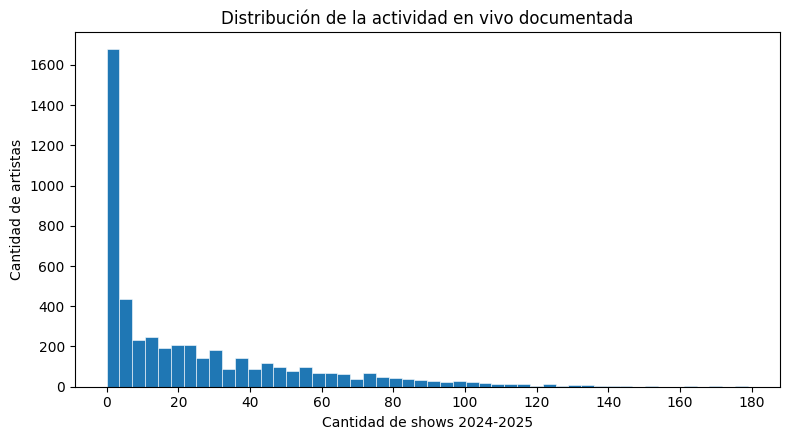

In [50]:
# ============================================================
# Paso 10. Distribución de la variable target
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

target = "n_shows_24_25"

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    df[target],
    bins=50,
    edgecolor="white",
    linewidth=0.4
)

ax.set_title("Distribución de la actividad en vivo documentada")
ax.set_xlabel("Cantidad de shows 2024-2025")
ax.set_ylabel("Cantidad de artistas")

ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# Paso 11. Distribución de la target: ceros y actividad positiva
# ============================================================

target_activity = pd.DataFrame({
    "grupo": [
        "0 shows",
        "> 0 shows"
    ],
    "n_artistas": [
        (df["n_shows_24_25"] == 0).sum(),
        (df["n_shows_24_25"] > 0).sum()
    ]
})

target_activity["pct"] = (
    target_activity["n_artistas"] / len(df) * 100
).round(2)

target_activity

,grupo,n_artistas,pct
0,0 shows,860,17.5
1,> 0 shows,4053,82.5


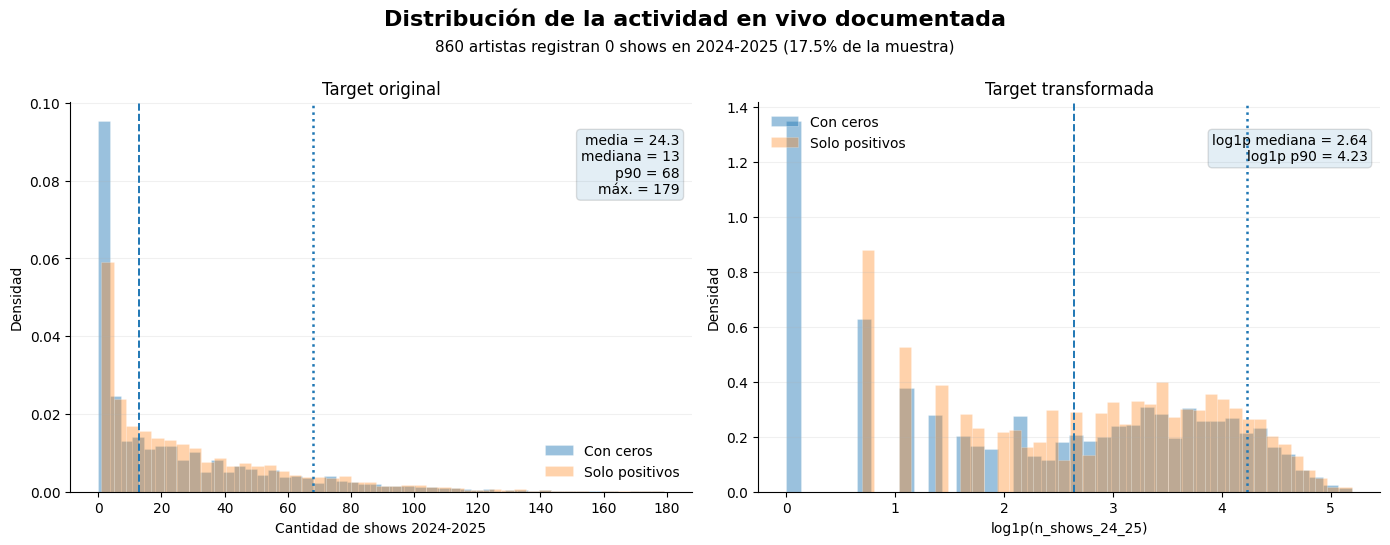

In [53]:
# ============================================================
# Panel exploratorio de la variable target n_shows_24_25
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

try:
    from scipy.stats import gaussian_kde
    kde_disponible = True
except Exception:
    kde_disponible = False

target = "n_shows_24_25"

s_all = df[target].astype(float)
s_pos = s_all[s_all > 0]

n_total = len(s_all)
n_zero = (s_all == 0).sum()
pct_zero = n_zero / n_total * 100

median_all = s_all.median()
mean_all = s_all.mean()
p90_all = s_all.quantile(0.90)

median_pos = s_pos.median()
mean_pos = s_pos.mean()
p90_pos = s_pos.quantile(0.90)

log_all = np.log1p(s_all)
log_pos = np.log1p(s_pos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

fig.suptitle(
    "Distribución de la actividad en vivo documentada",
    fontsize=16,
    fontweight="bold",
    y=1.04
)

fig.text(
    0.5,
    0.96,
    f"{n_zero} artistas registran 0 shows en 2024-2025 ({pct_zero:.1f}% de la muestra)",
    ha="center",
    fontsize=11
)

# ------------------------------------------------------------
# 1. Target original
# ------------------------------------------------------------

ax = axes[0]

ax.hist(
    s_all,
    bins=50,
    density=True,
    alpha=0.45,
    edgecolor="white",
    linewidth=0.4,
    label="Con ceros"
)

ax.hist(
    s_pos,
    bins=45,
    density=True,
    alpha=0.35,
    edgecolor="white",
    linewidth=0.4,
    label="Solo positivos"
)

if kde_disponible:
    x_grid_all = np.linspace(s_all.min(), s_all.max(), 500)
    kde_all = gaussian_kde(s_all)
    ax.plot(
        x_grid_all,
        kde_all(x_grid_all),
        linewidth=2
    )

    x_grid_pos = np.linspace(s_pos.min(), s_pos.max(), 500)
    kde_pos = gaussian_kde(s_pos)
    ax.plot(
        x_grid_pos,
        kde_pos(x_grid_pos),
        linewidth=2,
        linestyle="--"
    )

ax.axvline(median_all, linestyle="--", linewidth=1.4)
ax.axvline(p90_all, linestyle=":", linewidth=1.8)

ax.set_title("Target original")
ax.set_xlabel("Cantidad de shows 2024-2025")
ax.set_ylabel("Densidad")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax.text(
    0.98,
    0.92,
    f"media = {mean_all:.1f}\nmediana = {median_all:.0f}\np90 = {p90_all:.0f}\nmáx. = {s_all.max():.0f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.12)
)

ax.legend(frameon=False)

# ------------------------------------------------------------
# 2. Target transformada con log1p
# ------------------------------------------------------------

ax = axes[1]

ax.hist(
    log_all,
    bins=40,
    density=True,
    alpha=0.45,
    edgecolor="white",
    linewidth=0.4,
    label="Con ceros"
)

ax.hist(
    log_pos,
    bins=40,
    density=True,
    alpha=0.35,
    edgecolor="white",
    linewidth=0.4,
    label="Solo positivos"
)

if kde_disponible:
    x_grid_all = np.linspace(log_all.min(), log_all.max(), 500)
    kde_all = gaussian_kde(log_all)
    ax.plot(
        x_grid_all,
        kde_all(x_grid_all),
        linewidth=2
    )

    x_grid_pos = np.linspace(log_pos.min(), log_pos.max(), 500)
    kde_pos = gaussian_kde(log_pos)
    ax.plot(
        x_grid_pos,
        kde_pos(x_grid_pos),
        linewidth=2,
        linestyle="--"
    )

ax.axvline(np.log1p(median_all), linestyle="--", linewidth=1.4)
ax.axvline(np.log1p(p90_all), linestyle=":", linewidth=1.8)

ax.set_title("Target transformada")
ax.set_xlabel("log1p(n_shows_24_25)")
ax.set_ylabel("Densidad")

ax.text(
    0.98,
    0.92,
    f"log1p mediana = {np.log1p(median_all):.2f}\nlog1p p90 = {np.log1p(p90_all):.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.12)
)

ax.legend(frameon=False)

# ------------------------------------------------------------
# Ajustes generales
# ------------------------------------------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.18)

plt.tight_layout()
plt.show()

## curva lorenz

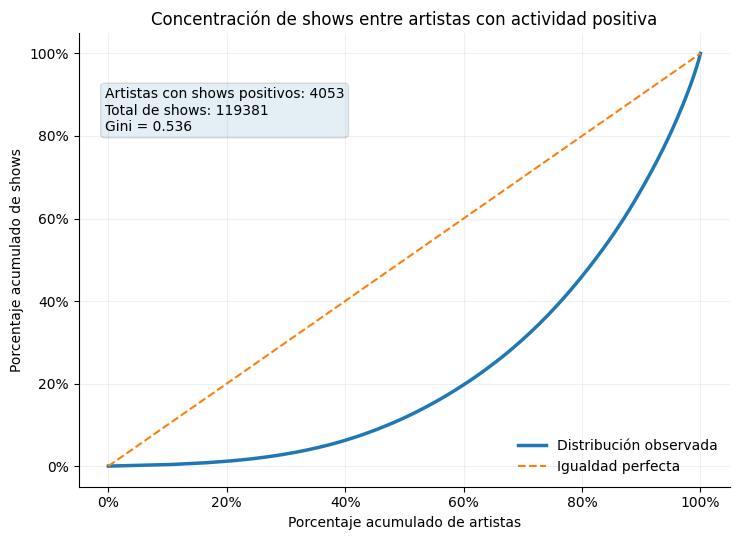

In [55]:
# ============================================================
# Paso 11. Concentración de shows entre artistas con actividad positiva
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

target = "n_shows_24_25"

s_pos = df.loc[df[target] > 0, target].astype(float).sort_values().reset_index(drop=True)

n_artistas_pos = len(s_pos)
total_shows_pos = s_pos.sum()

cum_artistas = np.arange(1, n_artistas_pos + 1) / n_artistas_pos
cum_shows = s_pos.cumsum() / total_shows_pos

cum_artistas = np.insert(cum_artistas, 0, 0)
cum_shows = np.insert(cum_shows, 0, 0)

gini = 1 - 2 * np.trapezoid(cum_shows, cum_artistas)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.plot(
    cum_artistas,
    cum_shows,
    linewidth=2.5,
    label="Distribución observada"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Igualdad perfecta"
)

ax.set_title("Concentración de shows entre artistas con actividad positiva")
ax.set_xlabel("Porcentaje acumulado de artistas")
ax.set_ylabel("Porcentaje acumulado de shows")

ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

ax.text(
    0.04,
    0.88,
    f"Artistas con shows positivos: {n_artistas_pos}\nTotal de shows: {total_shows_pos:.0f}\nGini = {gini:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.12)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.18)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# Concentración de shows en el top 20% de artistas con actividad positiva
# ============================================================

target = "n_shows_24_25"

s_pos = df.loc[df[target] > 0, target].astype(float)

umbral_top_20 = s_pos.quantile(0.80)

shows_top_20 = s_pos[s_pos >= umbral_top_20].sum()
shows_total_pos = s_pos.sum()

pct_shows_top_20 = shows_top_20 / shows_total_pos * 100
n_artistas_top_20 = (s_pos >= umbral_top_20).sum()
pct_artistas_top_20 = n_artistas_top_20 / len(s_pos) * 100

print("Umbral top 20%:", umbral_top_20)
print("Artistas en top 20%:", n_artistas_top_20)
print("Porcentaje de artistas:", round(pct_artistas_top_20, 2))
print("Porcentaje de shows concentrados:", round(pct_shows_top_20, 2))

Umbral top 20%: 52.0
Artistas en top 20%: 838
Porcentaje de artistas: 20.68
Porcentaje de shows concentrados: 55.22


# DISTRIBUCIONES

In [57]:
# ============================================================
# Paso 12. Subconjuntos de variables para EDA y modelado
# ============================================================

id_vars = [
    "chartmetric_id",
    "artist_name"
]

# ============================================================
# Metadata para EDA descriptivo y gráfico
# ============================================================

metadata_eda_vars = [
    "country_short",
    "genre_short",
    "pronoun_short",
    "band",
    "major_record_label"
]

# ============================================================
# Metadata de alta cardinalidad conservada para modelado posterior
# ============================================================

metadata_high_cardinality_vars = [
    "record_label",
    "country",
    "primary_genre",
    "pronoun_title"
]

digital_numeric_vars = (
    streaming_cols
    + playlist_cols
    + social_cols
    + youtube_cols
)

live_target_vars = [
    "n_shows_24_25"
]

live_aux_vars = [
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle",
    "muerto_disuelto"
]

vars_excluir_predictoras = (
    id_vars
    + live_target_vars
    + live_aux_vars
)


In [58]:
# ============================================================
# Variables candidatas para gráficos exploratorios
# ============================================================

eda_graph_vars = (
    metadata_eda_vars
    + digital_numeric_vars
    + ["n_shows_24_25"]
)

In [59]:
# ============================================================
# Verificación de clasificación de todas las variables
# ============================================================

subconjuntos = {
    "Identificación": id_vars,
    "Metadata EDA": metadata_eda_vars,
    "Metadata alta cardinalidad": metadata_high_cardinality_vars,
    "Variables digitales numéricas": digital_numeric_vars,
    "Target": live_target_vars,
    "Live auxiliares/derivadas": live_aux_vars
}

# Contar cuántas variables totales
total_vars = sum(len(v) for v in subconjuntos.values())
print(f"Total de variables clasificadas: {total_vars}")
print(f"Columnas en df: {df.shape[1]}\n")

# Resumen por bloque
for name, cols in subconjuntos.items():
    print(f"{name}: {len(cols)} variables")

# Verificación de que no quedó ninguna columna sin clasificar
clasificadas = [col for cols in subconjuntos.values() for col in cols]
no_clasificadas = sorted(set(df.columns) - set(clasificadas))
if no_clasificadas:
    print("\nColumnas no clasificadas:", no_clasificadas)
else:
    print("\nTodas las columnas han sido clasificadas correctamente.")

Total de variables clasificadas: 53
Columnas en df: 53

Identificación: 2 variables
Metadata EDA: 5 variables
Metadata alta cardinalidad: 4 variables
Variables digitales numéricas: 33 variables
Target: 1 variables
Live auxiliares/derivadas: 8 variables

Todas las columnas han sido clasificadas correctamente.


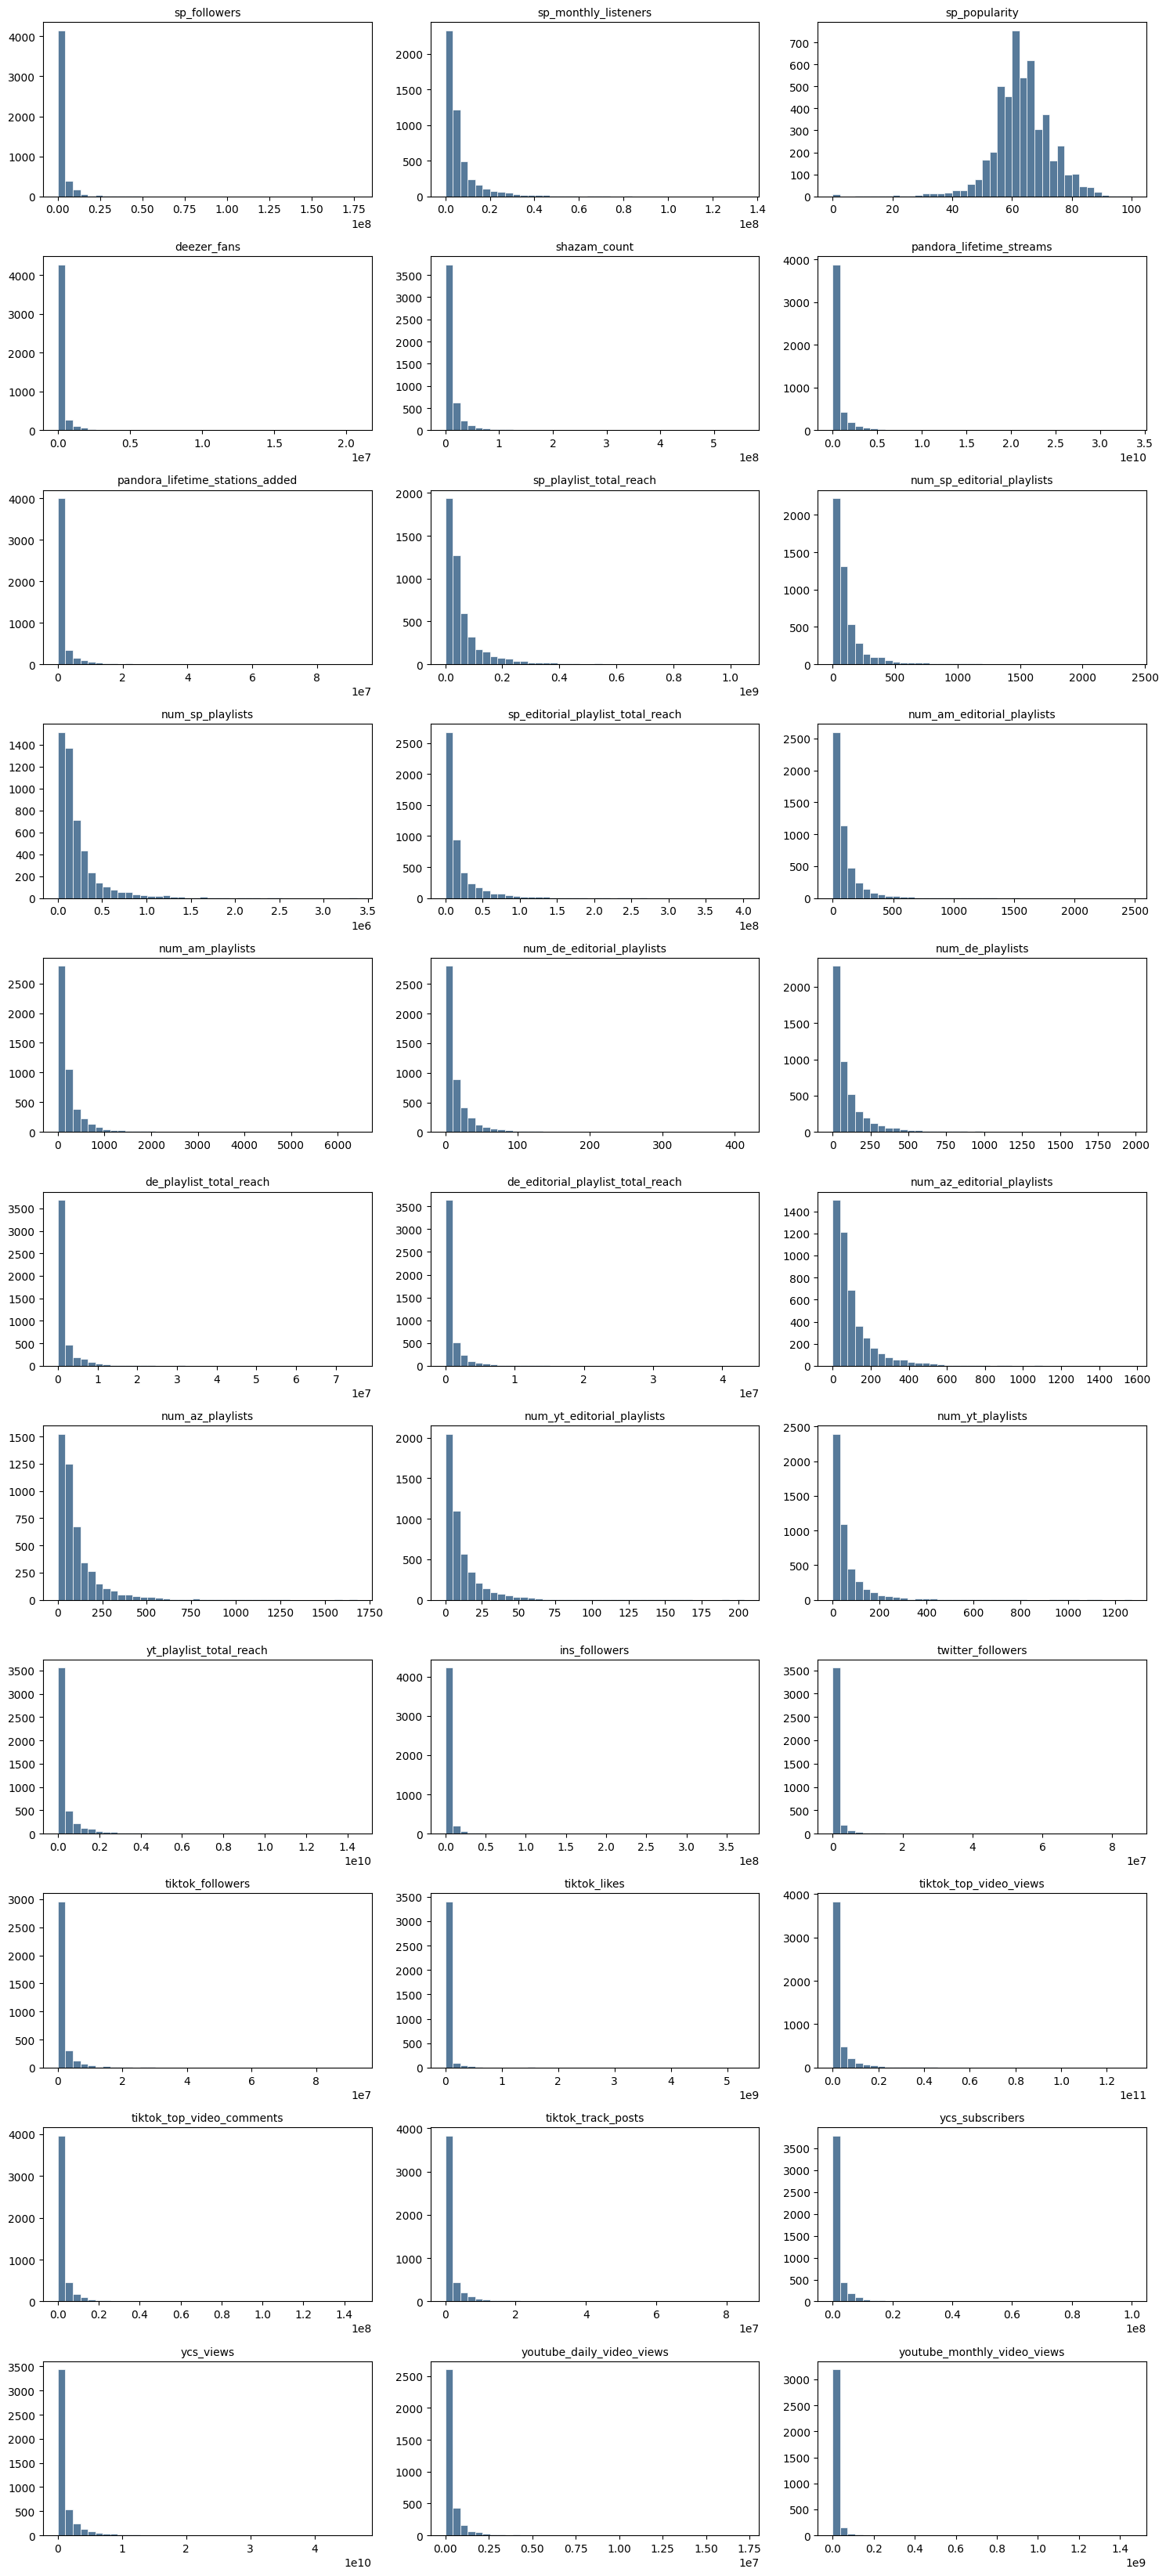

In [63]:
# ============================================================
# Distribución de variables digitales numéricas para EDA
# ============================================================

import seaborn as sns

# Seleccionar variables para gráficos
eda_num_vars = digital_numeric_vars

# Configuración del panel
n_cols = 3
n_rows = int(np.ceil(len(eda_num_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(eda_num_vars):
    sns.histplot(
        df[col].dropna(),
        bins=40,
        ax=axes[i],
        color="#1F4E79",
        edgecolor="white",
        linewidth=0.5
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Quitar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

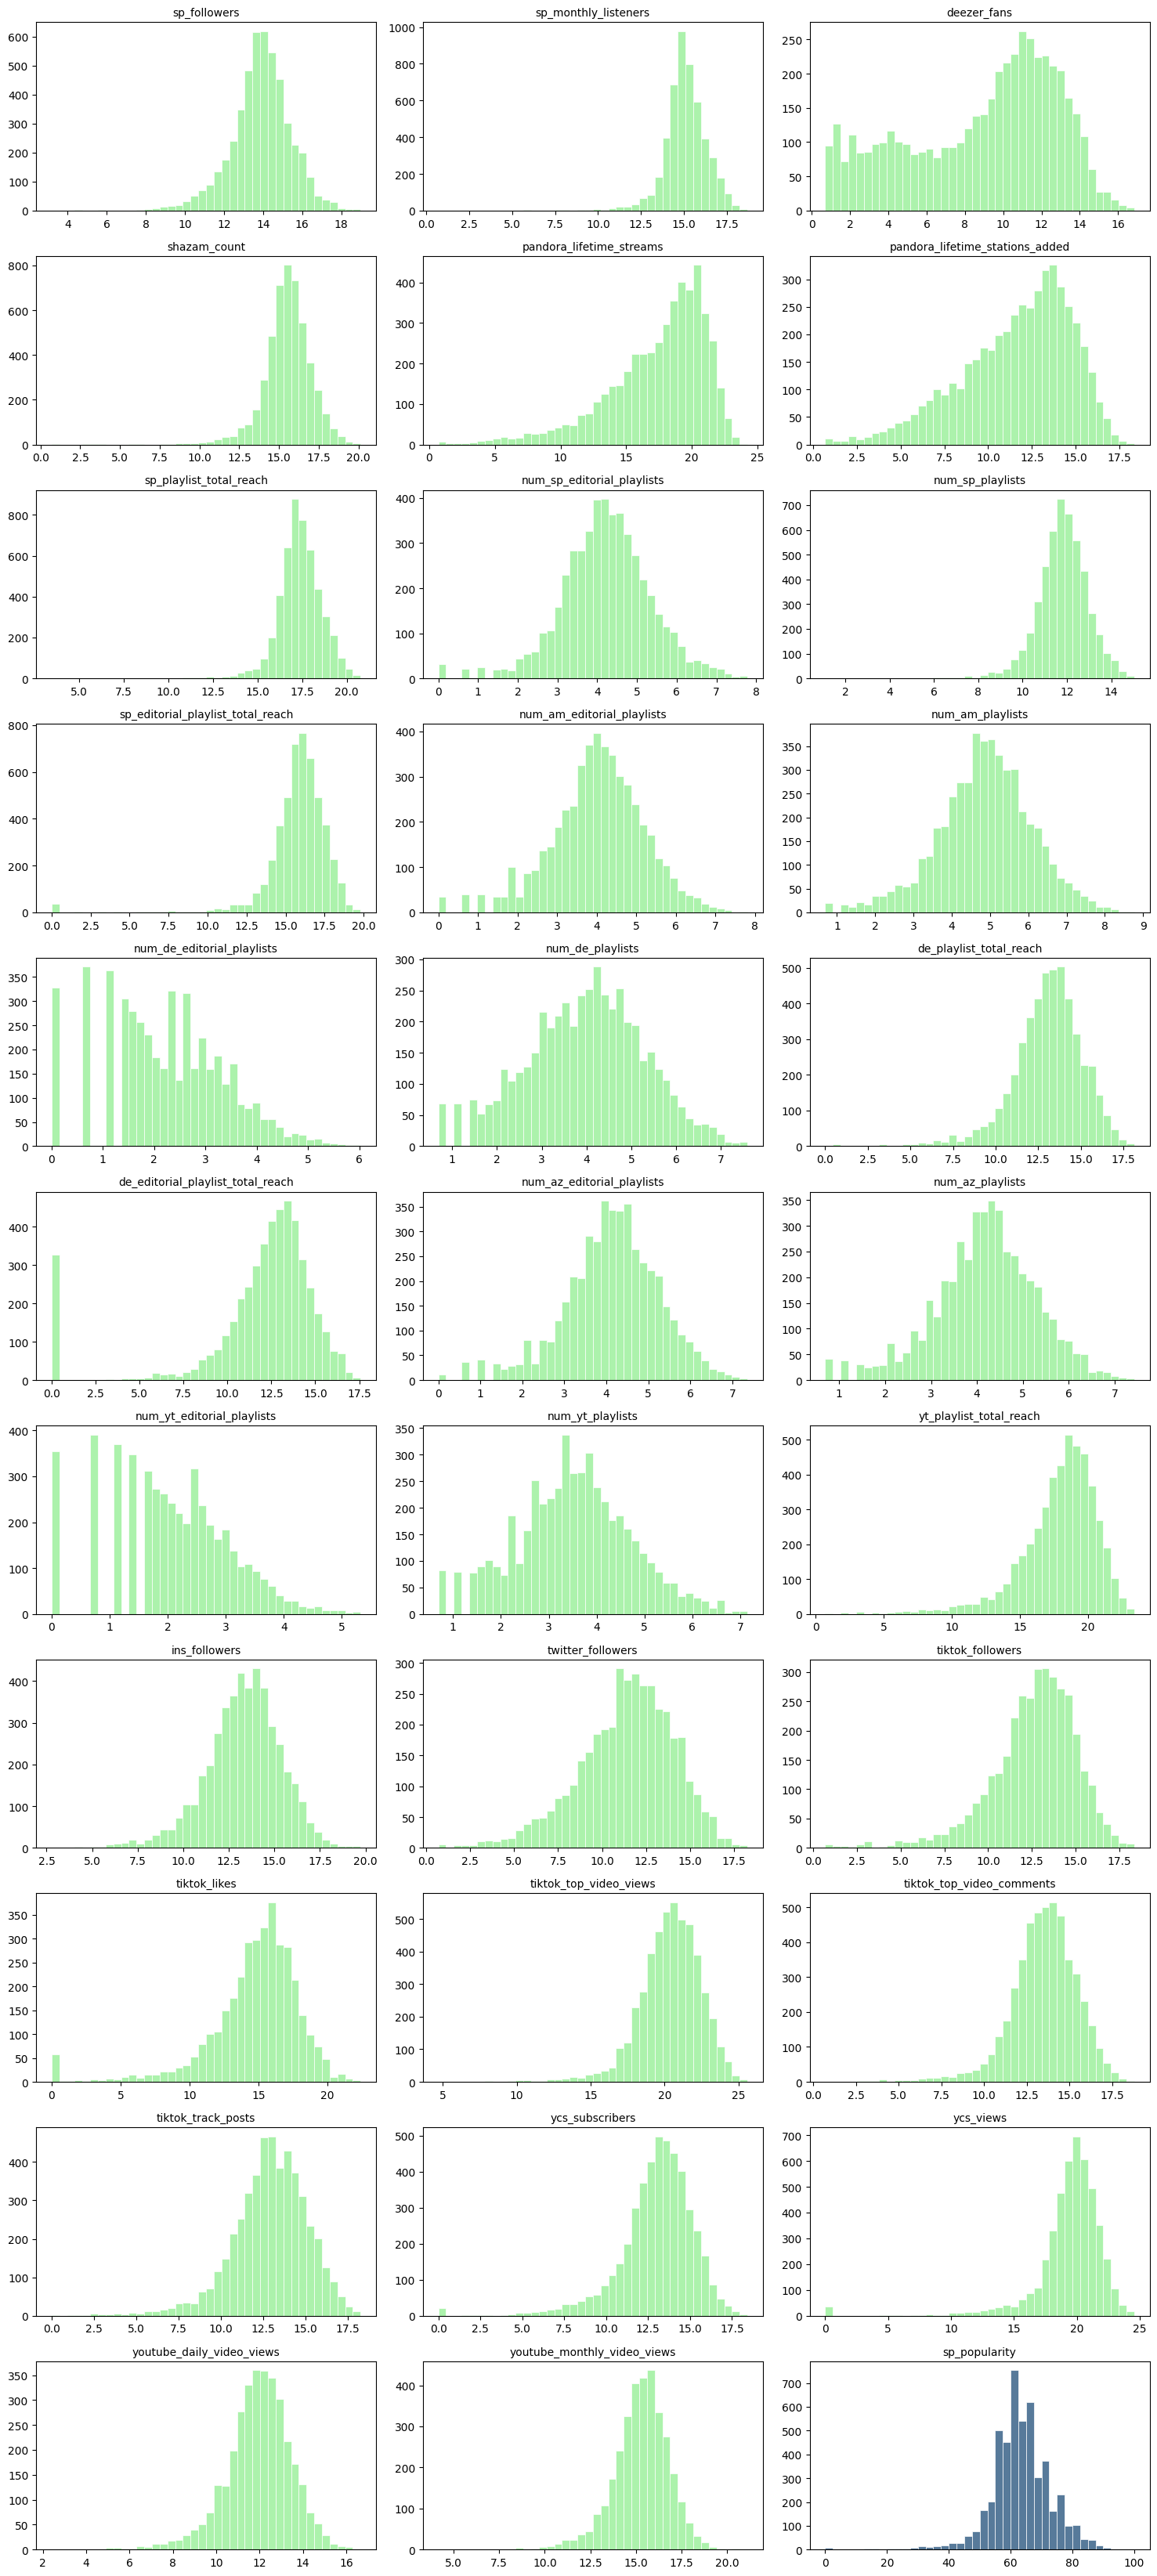

In [65]:
# ============================================================
# Panel de histogramas con log1p (verde claro) y sp_popularity en azul
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Variables a graficar
num_vars = digital_numeric_vars  # todas las variables numéricas
num_vars_plot = num_vars.copy()
# Nos aseguramos que sp_popularity esté al final para aplicarle color azul
num_vars_plot.remove("sp_popularity")
num_vars_plot.append("sp_popularity")

n_cols = 3
n_rows = int(np.ceil(len(num_vars_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_vars_plot):
    ax = axes[i]
    s = df[col].dropna().astype(float)
    
    # Aplicar log1p a todas menos sp_popularity
    if col != "sp_popularity":
        s_plot = np.log1p(s)
        color = "#90EE90"  # verde claro
    else:
        s_plot = s
        color = "#1F4E79"  # azul original
    
    sns.histplot(
        s_plot,
        bins=40,
        ax=ax,
        color=color,
        edgecolor="white",
        linewidth=0.5
    )
    
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

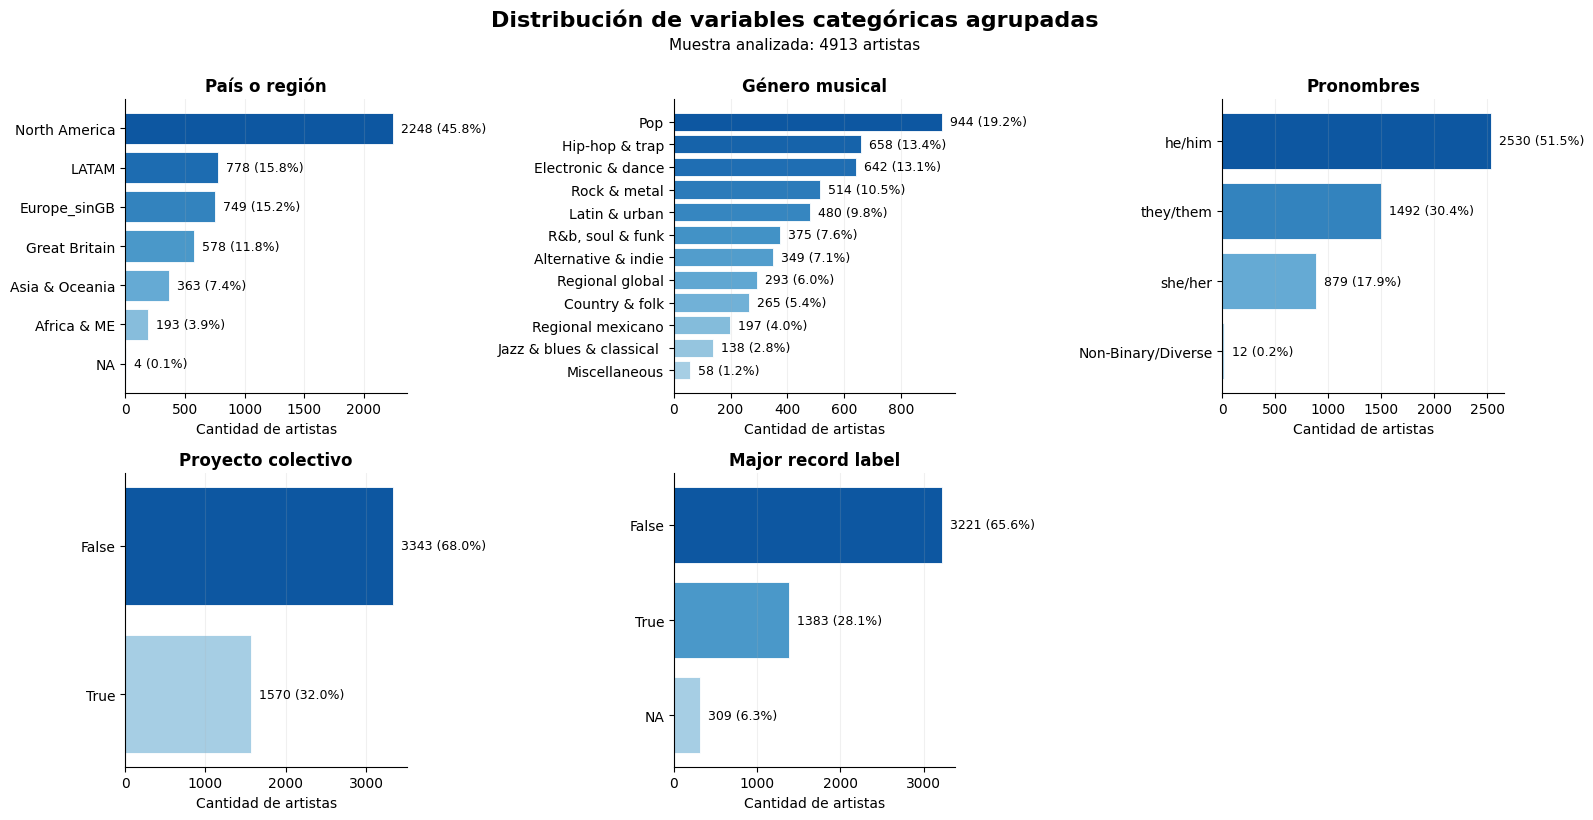

In [67]:
# ============================================================
# Panel estético de variables categóricas resumidas
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

cat_vars = [
    "country_short",
    "genre_short",
    "pronoun_short",
    "band",
    "major_record_label"
]

titulos = {
    "country_short": "País o región",
    "genre_short": "Género musical",
    "pronoun_short": "Pronombres",
    "band": "Proyecto colectivo",
    "major_record_label": "Major record label"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

fig.suptitle(
    "Distribución de variables categóricas agrupadas",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.97,
    f"Muestra analizada: {len(df)} artistas",
    ha="center",
    fontsize=11
)

for i, col in enumerate(cat_vars):
    ax = axes[i]

    freq = (
        df[col]
        .astype("string")
        .fillna("NA")
        .value_counts(dropna=False)
        .sort_values(ascending=True)
    )

    labels = freq.index.tolist()
    values = freq.values
    pct = values / values.sum() * 100

    colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(values)))

    bars = ax.barh(
        labels,
        values,
        color=colors,
        edgecolor="white",
        linewidth=0.6
    )

    ax.set_title(titulos[col], fontsize=12, fontweight="bold")
    ax.set_xlabel("Cantidad de artistas", fontsize=10)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.18)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, v, p in zip(bars, values, pct):
        ax.text(
            v,
            bar.get_y() + bar.get_height() / 2,
            f"  {v} ({p:.1f}%)",
            va="center",
            fontsize=9
        )

# Ocultar subplot vacío
for j in range(len(cat_vars), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()